In [31]:
import numpy as np
from auxiliares import cargar_datos_csv

In [ ]:
class layer():
    """Clase capa:
    
    atributos de clase:
        n_neuronas, n_inputs, weights, outputs, activate, activate_derivative, deltas"""

    def __init__(self, n_neurons, n_inputs, activation_function):
        self.n_neurons = n_neurons
        self.n_inputs = n_inputs
        self.weights = np.random.uniform(-0.5, 0.5, (self.n_neurons, self.n_inputs+1))
        self.activate_function_name = activation_function  
        self.deltas = np.zeros((n_neurons,1))

        match activation_function:
            case 'sigmoid':
                self.activate = self.sigmoid # 0,1
                self.activate_derivative = self.sigmoid_derivative
            case 'relu':
                self.activate = self.relu
                self.activate_derivative = self.relu_derivative
            case 'symmetry sigmoid':
                self.activate = self.symmetry_sigmoid # -1,1
                self.activate_derivative = self.symmetry_sigmoid_derivative
            case 'identity':
                self.activate = self.identity
                self.activate_derivative = self.identity_derivative
            case 'sign':
                self.activate = self.sign
                self.activate_derivative = self.sign_derivative
           
    def forward(self, inputs):
        """
        recibe un input con bias incluido como columna
        """

        self.inputs = inputs # SIN BIAS, LO AGREGAMOS AHORA

        input_bias = np.vstack((-1, inputs)) #agrego bias a la entrada
        
        self.outputs = self.activate(self.weights @ input_bias)
        return self.outputs #retorna columna
    

    def calculate_deltas(self, error):
        salida = self.activate_derivative(self.outputs) #aca esta el 1/2 en la derivada
         
        for i in range(salida.shape[0]):
            self.deltas[i] = error[i] * salida[i]

        return self.deltas #retorna columna

    
    
    ##funciones auxiliares
    def sigmoid(self, v):
        return 1 / (1 + np.exp(-v)) #0.1
    
    def sigmoid_derivative(self, v):
        return self.sigmoid(v) * (1 - self.sigmoid(v))
    
    def relu(self, v):
        return np.maximum(0, v)
    def relu_derivative(self, v):
        return np.where(v > 0, 1, 0)
    
    def symmetry_sigmoid(self, v):
        return 2 / (1 + np.exp(-v)) - 1
    def symmetry_sigmoid_derivative(self, v):
        return 0.5 * (1 + self.symmetry_sigmoid(v)) * (1 - self.symmetry_sigmoid(v)) 
    
    def identity(self, v):
        return v
    def identity_derivative(self, v):
        return np.ones_like(v)
    
    def sign(self, v):
        return np.where(v >= 0, 1, -1)
    def sign_derivative(self, v):
        return np.zeros_like(v)
    


In [ ]:
class neural_network():
    def __init__(self, layers_config, size_input, max_epoch=1000, learning_rate =0.01, error_threshold=1e-6):
        """"Layers config es una lista de tuplas (n_neurons, activation_function)"""
        self.layers = []
        for i in range(len(layers_config)):
            neurons, activation = layers_config[i]
            self.layers.append(
                layer(
                    n_neurons = neurons,
                    n_inputs = size_input  if i==0 else layers_config[i-1][0], #entrada o cantidad de neuronas anterior
                    activation_function = activation
                )
            )
        self.max_epoch = max_epoch
        self.learning_rate = learning_rate
        self.error_threshold = error_threshold
        self.epoch_error = []

    def fit(self, X, y):
        if y.ndim ==1:
            y = y.reshape(-1,1)
        
        #X = np.hstack((-1*np.ones((X.shape[0], 1)), X))
        for epoch in range(self.max_epoch):
            for i in range(X.shape[0]):
                x_current = np.array(X[i,:]).reshape(-1,1) #no le agregamos todavia el bias
                y_current = np.array(y[i,:]).reshape(-1,1) #pueden ser mas de una salida!!!!!!!
                self.forward_propagation(x_current) #lo pasamos como columna!!!!!!!!!!!!!!!
                self.backward_propagation(y_current)
                self._update_weights()
            epoch_error = self.calculate_error_epoc(X, y)
            print(f"Época: {epoch} - Errorcito: {epoch_error}")
            self.epoch_error.append(epoch_error)
            if epoch_error < self.error_threshold:
                break

    def transform(self, X):
        y_pred = []
        for i in range(X.shape[0]):
            x_curr = np.array(X[i]).reshape(-1,1) #hacerlo columna
            y_pred.append(self.forward_propagation(x_curr))

        return np.array(y_pred)
         
    def score(self, X, y):
        #funcion de score para clasificacion / regresion
        is_classification = False
        if self.layers[-1].activate_function_name in ['sigmoid', 'symmetry sigmoid', 'sign', 'tanh']:
            is_classification = True

        if is_classification == True:
            match self.layers[-1].activate_function_name:
                #diferenciamos casos para la funcion de salida
                case 'symmetry sigmoid' | 'sign':
                    correct = 0
                    total = len(X)

                    for i in range(total):
                        x = X[i].reshape(-1,1)
                        output = self.forward_propagation(x)

                        pred_class = np.argmax(output)      # índice del mayor
                        true_class = np.argmax(y[i])        # índice del 1 (o del 1 en [-1,1])

                        if pred_class == true_class:
                            correct += 1
                    return correct / total #retorna la acuracy
                case 'sigmoide':
                    #tiene los indices de 0,1
                    pass
        else:
            #identity, relu
            y_pred = self.transform(X).flatten()
            mse = np.mean((y_pred - y.flatten())**2)
            return mse



    def forward_propagation(self, x):
        # recorrer capa por capa hasta llegar a la salida
        #siempre es vector
        for i, layer in enumerate(self.layers):
            if i == 0:
                self.layers[i].forward(x)
            else:
                self.layers[i].forward(self.layers[i-1].outputs)

        return self.layers[-1].outputs
    
    def backward_propagation(self, y):
        #i = recorrer capa anterior, cantidad de entradas de actual
        #j recorrer capa actual
        # k recorrer todas la capa de salida

        for layer_index in range(len(self.layers)-1, -1,-1): #recorro todas las capas
            current_layer = self.layers[layer_index]
            if layer_index == len(self.layers)-1: #capa de salida
                error = current_layer.outputs - y #predicho - real (puede ser mas de una salida)
                current_layer.calculate_deltas(error) 
            else:
                next_layer = self.layers[layer_index + 1] #de aca saco el delta de la capa siguiente
                error_propagado = []

                for i in range(current_layer.n_neurons):  # i = neurona actual
                    suma = 0
                    # Sumar contribuciones de todas las neuronas de la SIGUIENTE capa
                    for j in range(next_layer.deltas.shape[0]):
                        # next_layer.weights[j, i+1] donde:
                        # j: neurona siguiente
                        # i+1: neurona actual (sesgo incluido)
                        suma += next_layer.deltas[j] * next_layer.weights[j, i+1]
                    error_propagado.append(suma)
                
                error_propagado = np.array(error_propagado).reshape(-1, 1)
                current_layer.calculate_deltas(error_propagado)

            
    def _update_weights(self):
        for layer_index in range(len(self.layers)):
            #recorro todas las capas
            current_layer = self.layers[layer_index]
            for j in range(current_layer.n_neurons):
                #recorro todas las neuronas de la capa actual
                for i in range(current_layer.n_inputs+1):
                    #producto punto
                    if i == 0:
                        current_layer.weights[j,i] -= self.learning_rate * current_layer.deltas[j].item() * -1
                    else: 
                        current_layer.weights[j,i] -= self.learning_rate * current_layer.deltas[j].item() * current_layer.inputs[i-1].item()


    def calculate_error_epoc(self, X, y):
        y_pred = []

        #predicciones renglon por renglon
        for i in range(X.shape[0]):
            y_pred.append(self.forward_propagation(X[i,:].reshape(-1,1)).flatten()) #pasar como columna

        y_pred = np.array(y_pred)
        error = (y_pred-y)**2
        error = error.sum()
        return error
        


                




In [38]:
import os
import matplotlib.pyplot as plt

ruta_actual = os.getcwd()

#intentamos xor !!!!!!


X_train, y_train = cargar_datos_csv(os.path.join(ruta_actual, '../data/diabetes_trn.csv'))
X_test, y_test = cargar_datos_csv(os.path.join(ruta_actual, '../data/diabetes_tst.csv'))

n_netw= neural_network(
    layers_config = [(4, 'symmetry sigmoid'), (1, 'identity')],
    size_input = X_train.shape[1],
    max_epoch=100,
    learning_rate=0.01,
    error_threshold=1e-6
)

n_netw.fit(X_train, y_train)

y_pred = n_netw.transform(X_test).flatten()

print(n_netw.score(X_test, y_test))

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
Época: 0 - Errorcito: 2174974.849691067
Época: 1 - Errorcito: 2171752.2982645426
Época: 2 - Errorcito: 1914552.0591214779
Época: 3 - Errorcito: 1799650.874645561
Época: 4 - Errorcito: 1846337.3845519084
Época: 5 - Errorcito: 1894649.8497438754
Época: 6 - Errorcito: 1929800.0660271414
Época: 7 - Errorcito: 1993165.106270033
Época: 8 - Errorcito: 1924124.4716388693


C:\Users\MATEOCRACK\AppData\Local\Temp\ipykernel_18720\805531544.py:65: RuntimeWarning: overflow encountered in exp
  return 2 / (1 + np.exp(-v)) - 1


Época: 9 - Errorcito: 1932385.453463612
Época: 10 - Errorcito: 1944267.4372623623
Época: 11 - Errorcito: 1977052.3217643644
Época: 12 - Errorcito: 1928499.9990489883
Época: 13 - Errorcito: 1898860.8017928377
Época: 14 - Errorcito: 1869969.4144327226
Época: 15 - Errorcito: 1795734.4436252909
Época: 16 - Errorcito: 1734298.9469489222
Época: 17 - Errorcito: 1729699.2266729227
Época: 18 - Errorcito: 1696647.479582563
Época: 19 - Errorcito: 1686036.5381765212
Época: 20 - Errorcito: 1707753.3739804616
Época: 21 - Errorcito: 1729835.1953377142
Época: 22 - Errorcito: 1750281.6568435864
Época: 23 - Errorcito: 1725853.29426855
Época: 24 - Errorcito: 1713588.8160367256
Época: 25 - Errorcito: 1705789.6529092693
Época: 26 - Errorcito: 1703421.5125273769
Época: 27 - Errorcito: 1705843.4653508975
Época: 28 - Errorcito: 1705834.4595633787
Época: 29 - Errorcito: 1705139.3120262227
Época: 30 - Errorcito: 1705414.2388124452
Época: 31 - Errorcito: 1723224.6176291923
Época: 32 - Errorcito: 1713252.21352081

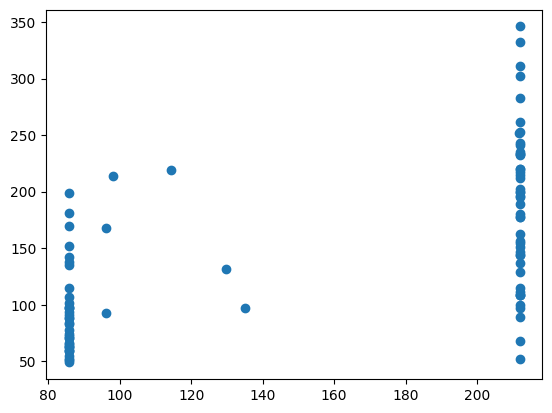

In [36]:
plt.plot(y_pred, y_test.flatten(), 'o')